# Logistic Regression From Scratch

A simple, beginner-friendly implementation of Logistic Regression using only Python, NumPy, pandas, and matplotlib — no machine learning libraries.

## 1. Introduction

**Logistic Regression** is a supervised machine learning algorithm used for **binary classification** — predicting one of two possible classes (e.g. "will buy" vs "won't buy").

Instead of predicting a class directly, it predicts a **probability** between 0 and 1 using the **Sigmoid function**. If the probability is 0.5 or higher, we predict class `1`; otherwise, we predict class `0`.

The animation below shows our own model learning the decision boundary on the actual dataset used in this notebook, iteration by iteration:

![Logistic Regression Animation](GIF/logistic_regression.gif)

As training progresses, the boundary moves until it best separates the two classes (red = purchased, blue = not purchased).

## 2. Load and Explore the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('datasets/Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


**About the dataset:**

- **Features used:** `Age` and `EstimatedSalary`
- **Target variable:** `Purchased` (0 = did not purchase, 1 = purchased)
- **Problem type:** Binary classification
- **Classes:** `0` and `1`

## 3. The Math Behind Logistic Regression

**Linear combination** — combine the features with weights (`w`) and a bias (`b`):

$$z = Xw + b$$

**Sigmoid function** — squashes `z` into a probability between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

**Classification decision** — turn the probability into a class using a threshold of 0.5:

$$\hat{y} = 1 \text{ if } p \geq 0.5, \text{ else } 0$$

**Loss function (Binary Cross-Entropy)** — measures how wrong the predictions are:

$$J(w,b) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]$$

**Gradient Descent** — repeatedly nudges `w` and `b` in the direction that reduces the loss, using the gradients of `J` with respect to `w` and `b`.

## 4. Data Preprocessing

Steps:
1. Select the input features and target.
2. Split manually into training and testing sets.
3. Standardize the features manually.

In [2]:
# Select features and target
X = df[['Age', 'EstimatedSalary']].values.astype(float)
y = df['Purchased'].values.astype(float)

print(X.shape, y.shape)

(400, 2) (400,)


In [3]:
# Manual train/test split (80% train, 20% test)
np.random.seed(42)
indices = np.arange(len(X))
np.random.shuffle(indices)

split = int(0.8 * len(indices))
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 320
Test size: 80


In [4]:
# Manual standardization: (X - mean) / std
# We compute mean/std on the TRAINING set only, then apply it to both sets
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

## 5. Logistic Regression Implementation

A small class implementing the algorithm from scratch: initialize parameters, compute the linear combination, apply Sigmoid, compute gradients, and update the parameters with Gradient Descent.

In [5]:
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias at zero
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self.n_iterations):
            # Linear combination + Sigmoid -> predicted probabilities
            z = X.dot(self.weights) + self.bias
            y_pred = self._sigmoid(z)

            # Binary Cross-Entropy loss (small epsilon avoids log(0))
            eps = 1e-9
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.loss_history.append(loss)

            # Gradients of the loss with respect to weights and bias
            dw = (1 / n_samples) * X.T.dot(y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Gradient Descent update
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        z = X.dot(self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## 6. Model Training

During training, the model repeatedly computes predictions, measures the loss, and updates `w` and `b` with Gradient Descent. Since each update moves the parameters in the direction that reduces the loss, the loss should generally go down over time.

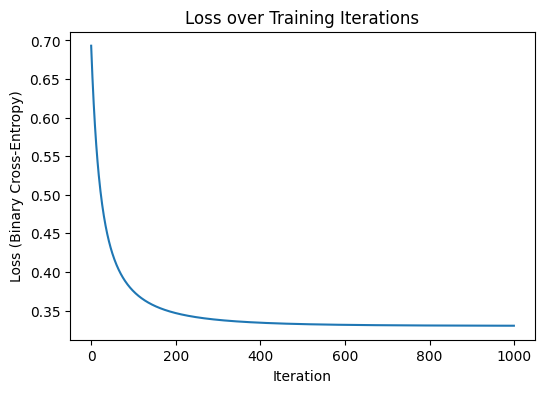

In [12]:
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(X_train_scaled, y_train)

plt.figure(figsize=(6, 4))
plt.plot(model.loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss (Binary Cross-Entropy)')
plt.title('Loss over Training Iterations')
plt.show()

## 7. Model Evaluation

We check how well the model performs on the **test set**, which it has never seen during training.

In [7]:
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.86


In [8]:
# Confusion Matrix, computed manually
TP = np.sum((y_pred == 1) & (y_test == 1))
TN = np.sum((y_pred == 0) & (y_test == 0))
FP = np.sum((y_pred == 1) & (y_test == 0))
FN = np.sum((y_pred == 0) & (y_test == 1))

print("Confusion Matrix")
print(f"                Predicted 0   Predicted 1")
print(f"Actual 0        {TN:<13}{FP}")
print(f"Actual 1        {FN:<13}{TP}")

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

Confusion Matrix
                Predicted 0   Predicted 1
Actual 0        49           6
Actual 1        5            20

Precision: 0.77
Recall:    0.80
F1-Score:  0.78


## 8. Visualizing the Decision Boundary

Since we used exactly two features (`Age` and `EstimatedSalary`), we can plot the decision boundary directly.

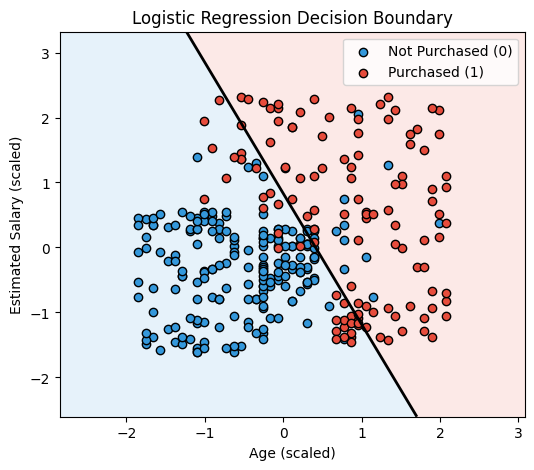

In [9]:
x1_min, x1_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
x2_min, x2_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 200),
                        np.linspace(x2_min, x2_max, 200))
grid = np.c_[xx1.ravel(), xx2.ravel()]
probs = model.predict_proba(grid).reshape(xx1.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx1, xx2, probs, levels=[0, 0.5, 1], colors=['#d6eaf8', '#fadbd8'], alpha=0.6)
plt.contour(xx1, xx2, probs, levels=[0.5], colors='black', linewidths=2)

plt.scatter(X_train_scaled[y_train == 0][:, 0], X_train_scaled[y_train == 0][:, 1],
            color='#3498db', edgecolor='k', label='Not Purchased (0)')
plt.scatter(X_train_scaled[y_train == 1][:, 0], X_train_scaled[y_train == 1][:, 1],
            color='#e74c3c', edgecolor='k', label='Purchased (1)')

plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

## 9. Conclusion

In this notebook we built Logistic Regression **from scratch**:

- The model combines features linearly (`z = Xw + b`).
- The **Sigmoid function** turns that linear output into a probability between 0 and 1.
- **Gradient Descent** trains the model by repeatedly adjusting `w` and `b` to reduce the Binary Cross-Entropy loss.
- Predictions are made by applying a **0.5 threshold** to the predicted probability.

The model reached a reasonable accuracy on unseen test data, and the decision boundary plot shows how it separates the two classes based on `Age` and `EstimatedSalary`. The biggest takeaway: Logistic Regression is just a linear model wrapped in a Sigmoid function, trained with Gradient Descent.